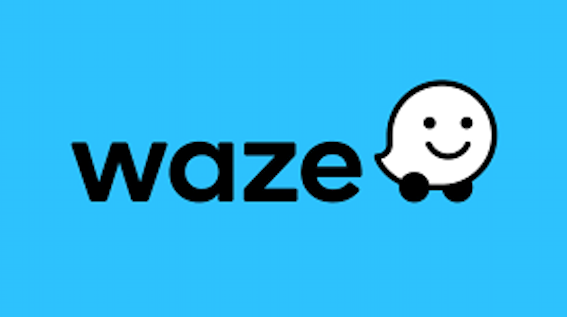

---

### SUMMARY

1. [Inspect and Analyze the Data](#1)
2. [Exploratory Data Analysis](#2)
3. [Hypothesis Testing](#3)
4. [Build a Logistic Regression Model](#4)
5. [Build a Machine Learning Model](#5)

---

Waze's free navigation app makes it easier for drivers around the world to get to where they want to go. Waze’s community of map editors, beta testers, translators, partners, and users helps make each drive better and safer. Waze partners with cities, transportation authorities, broadcasters, businesses, and first responders to help as many people as possible travel more efficiently and safely. 
<br>You will collaborate with your Waze teammates to analyze and interpret data, generate valuable insights, and help leadership make informed business decisions. Your team is about to start a new project to help prevent user churn on the Waze app. Churn quantifies the number of users who have uninstalled the Waze app or stopped using the app. This project focuses on monthly user churn. 

<a id="1"></a>
# 1. Inspect and Analyze the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score, \
f1_score,confusion_matrix,ConfusionMatrixDisplay,RocCurveDisplay,PrecisionRecallDisplay,roc_auc_score,roc_curve,auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier,plot_importance

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',None)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

**Read the Data**

In [ ]:
df = pd.read_csv("/kaggle/input/waze-dataset-to-predict-user-churn/waze_dataset.csv")

**View and inspect summary information about the dataframe**

In [ ]:
df.head()

In [ ]:
df.info()

Consider the following questions:

1. When reviewing the df.info() output, what are the data types? How many rows and columns do you have?
*There are 14999 rows and 13 columns, both numerical and non numerical.*

2. Does the dataset have any missing values?
*The column 'label' has 700 missing values.*

**Drop the unnecessary ID column.**

In [ ]:
df = df.drop('ID',axis=1)

**Null values and summary statistics**

Compare the summary statistics of the 700 rows that are missing labels with summary statistics of the rows that are not missing any values.

In [ ]:
# Isolate rows with null values
df_na = df[df['label'].isna()]

# Display summary stats of rows with null values
df_na.describe()

In [ ]:
# Isolate rows without null values
df_ok = df[~df['label'].isna()]

# Display summary stats of rows without null values
df_ok.describe()

Is there a discernible difference between the two populations?

*There are only some minor differences, nothing remarkable. The means and standard deviations are fairly consistent between the two groups.*

**Null values - device counts**

Next, check the two populations with respect to the device variable.

How many iPhone users had null values and how many Android users had null values?

In [ ]:
# Get count of null values by device
df_na['device'].value_counts()

Now, of the rows with null values, calculate the percentage with each device—Android and iPhone. You can do this directly with the value_counts() function.

In [ ]:
df_na['device'].value_counts(normalize=True)*100

How does this compare to the device ratio in the full dataset?

In [ ]:
df_ok['device'].value_counts(normalize=True)*100

The percentage of missing values by each device is consistent with their representation in the data overall. <br>
There is nothing to suggest a non-random cause of the missing data.

**Did/did not churn (retained)**

Examine the counts and percentages of users who churned vs. those who were retained. How many of each group are represented in the data?

In [ ]:
print('absolute values of churned vs retained')
print(df['label'].value_counts())

print()

print('percentage of churned vs retained')
print(df['label'].value_counts(normalize=True)*100)

In [ ]:
plt.figure(figsize=(12,6))

graph = df['label'].value_counts().plot(kind='barh',color=['orange','steelblue'])

plt.title('Churned vs retained users')
plt.xlabel('No. of users')
plt.ylabel('churned/retained')

plt.show()

Next, compare the medians of each variable for churned and retained users. The reason for calculating the median and not the mean is that you don't want outliers to unduly affect the portrayal of a typical user. <br>
Notice, for example, that the maximum value in the driven_km_drives column is 21,183 km. That's more than half the circumference of the earth!

In [ ]:
df.groupby(['label']).median(numeric_only=True)

This offers an interesting snapshot of the two groups, churned vs. retained: <br>
Users who churned averaged ~3 more drives in the last month than retained users, but retained users used the app on over twice as many days as churned users in the same time period. <br>
The median churned user drove ~200 more kilometers and 2.5 more hours during the last month than the median retained user. <br>
It seems that churned users had more drives in fewer days, and their trips were farther and longer in duration. Perhaps this is suggestive of a user profile. 

Calculate the median kilometers per drive in the last month for both retained and churned users. <br>
Begin by dividing the driven_km_drives column by the drives column. Then, group the results by churned/retained and calculate the median km/drive of each group.

In [ ]:
# Add a column to df called `km_per_drive`
df['km_per_drive'] = df['driven_km_drives'] / df['drives']

# Group by `label`, calculate the median, and isolate for km per drive
df.groupby('label')[['km_per_drive']].median()

The median retained user drove about one more kilometer per drive than the median churned user. How many kilometers per driving day was this?

To calculate this statistic, repeat the steps above using driving_days instead of drives.

In [ ]:
# Add a column to df called `km_per_driving_day`
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

# Group by `label`, calculate the median, and isolate for km per driving day
df.groupby('label')[['km_per_driving_day']].median()

Now, calculate the median number of drives per driving day for each group.

In [ ]:
# Add a column to df called `km_per_driving_day`
df['drives_per_driving_day'] = df['drives'] / df['driving_days']

# Group by `label`, calculate the median, and isolate for km per driving day
df.groupby('label')[['drives_per_driving_day']].median()

The median user who churned drove 698 kilometers each day they drove last month, which is almost ~240% the per-drive-day distance of retained users. The median churned user had a similarly disproporionate number of drives per drive day compared to retained users. <br>
It is clear from these figures that, regardless of whether a user churned or not, the users represented in this data are serious drivers! It would probably be safe to assume that this data does not represent typical drivers at large. Perhaps the data—and in particular the sample of churned users—contains a high proportion of long-haul truckers. <br>
In consideration of how much these users drive, it would be worthwhile to recommend to Waze that they gather more data on these super-drivers. It's possible that the reason for their driving so much is also the reason why the Waze app does not meet their specific set of needs, which may differ from the needs of a more typical driver, such as a commuter.

Finally, examine whether there is an imbalance in how many users churned by device type.

Begin by getting the overall counts of each device type for each group, churned and retained.

In [ ]:
# For each label, calculate the number of Android users and iPhone users
df.groupby('label')['device'].value_counts()

Now, within each group, churned and retained, calculate what percent was Android and what percent was iPhone.

In [ ]:
df.groupby('label')['device'].value_counts(normalize=True)*100

The ratio of iPhone users and Android users is consistent between the churned group and the retained group, and those ratios are both consistent with the ratio found in the overall dataset.

**Drop the columns that are unnecessary after completing the analysis**

In [ ]:
df.drop(columns=['km_per_drive','drives_per_driving_day'],inplace=True)

<a id="2"></a>
# 2. Exploratory Data Analysis

**Sessions.** Number of occurrences of a user opening the app during the month.

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4),constrained_layout = True)

ax1 = sns.boxplot(data=df,x='sessions',color='r',ax=ax1)
ax1.set_xlabel("sessions",fontsize=14)
ax1.set_title('Boxplot of sessions',fontsize=18)
ax1.set_yticklabels(ax1.get_yticks(),size=14)

median_sessions = np.median(df['sessions'])
ax2 = plt.hist(df['sessions'],bins=50,color='grey')
plt.axvline(median_sessions,color="red",ls="--",label="Median hour")
plt.xlabel('sessions',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.text(70,2200,'median of sessions = 56',color='red')
plt.title('Histogram of sessions',fontsize=18);

The *sessions* variable is a right-skewed distribution, with half of the observations having 56 or fewer sessions.

**Total_sessions.** A model estimate of the total number of sessions since a user has onboarded.

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4),constrained_layout = True)

ax1 = sns.boxplot(data=df,x='total_sessions',color='r',ax=ax1)
ax1.set_xlabel("total sessions",fontsize=14)
ax1.set_title('Boxplot of total sessions',fontsize=18)
ax1.set_yticklabels(ax1.get_yticks(),size=14)

median_sessions = np.median(df['total_sessions'])
ax2 = plt.hist(df['total_sessions'],bins=50,color='grey')
plt.axvline(median_sessions,color="red",ls="--",label="Median hour")
plt.xlabel('total_sessions',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.text(200,1300,'median of total sessions = 160',color='red')
plt.title('Histogram of total sessions',fontsize=18);

The *total_sessions* is a right-skewed distribution with a median value of 159.6. This is interesting information because, if the median number of sessions in the last month was 56 and the median total sessions was ~160, then it seems that a large proportion of a user's (estimated) total drives might have taken place in the last month. 

**Drives.** An occurrence of driving at least 1 km during the month.

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4),constrained_layout = True)

ax1 = sns.boxplot(data=df,x='drives',color='r',ax=ax1)
ax1.set_xlabel("drives",fontsize=14)
ax1.set_title('Boxplot of drives',fontsize=18)
ax1.set_yticklabels(ax1.get_yticks(),size=14)

median_drives = np.median(df['drives'])
ax2 = plt.hist(df['drives'],bins=50,color='grey')
plt.axvline(median_drives,color="red",ls="--",label="Median hour")
plt.xlabel('drives',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.text(70,2100,'median of drives = 48',color='red')
plt.title('Histogram of drives',fontsize=18);

The *drives* feature follows a distribution similar to that of *sessions*. 

**n_days_after_onboarding.** The number of days since a user signed up for the app.

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4),constrained_layout = True)

ax1 = sns.boxplot(data=df,x='n_days_after_onboarding',color='r',ax=ax1)
ax1.set_xlabel("no. of days after onboarding",fontsize=14)
ax1.set_title('Boxplot of no. of days after onboarding',fontsize=18)
ax1.set_yticklabels(ax1.get_yticks(),size=14)

median_onboard = np.median(df['n_days_after_onboarding'])
ax2 = plt.hist(df['n_days_after_onboarding'],bins=50,color='grey')
plt.axvline(median_onboard,color="red",ls="--",label="Median hour")
plt.xlabel('no. of days after onboarding',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.text(1800,350,'median of no. of days',color='red')
plt.text(1800,330,'after onboarding = 1741',color='red')
plt.title('Histogram of no. of days after onboarding',fontsize=18);

The total user tenure (i.e., number of days since onboarding) is a uniform distribution, with values ranging from near-zero to approx. 3500 (~9.5 years).

**driven_km_drives.** Total kilometers driven during the month.

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4),constrained_layout = True)

ax1 = sns.boxplot(data=df,x='driven_km_drives',color='r',ax=ax1)
ax1.set_xlabel("kms driven in the month",fontsize=14)
ax1.set_title('Boxplot of kms driven in the month',fontsize=18)
ax1.set_yticklabels(ax1.get_yticks(),size=14)

median_kms = np.median(df['driven_km_drives'])
ax2 = plt.hist(df['driven_km_drives'],bins=50,color='grey')
plt.axvline(median_kms,color="red",ls="--",label="Median hour")
plt.xlabel('kms driven in the month',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.text(3800,1250,'median of kms driven',color='red')
plt.text(3800,1180,'in the month = 3494',color='red')
plt.title('Histogram of kms driven in the month',fontsize=18);

The number of kms driven in the last month per user is a right-skewed distribution, with half the users driving less than 3500 kilometers. 

**duration_minutes_drives.** Total duration driven (in minutes) during the month.

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4),constrained_layout = True)

ax1 = sns.boxplot(data=df,x='duration_minutes_drives',color='r',ax=ax1)
ax1.set_xlabel("duration [minutes]",fontsize=14)
ax1.set_title('Boxplot of duration in the month',fontsize=18)
ax1.set_yticklabels(ax1.get_yticks(),size=14)

median_durmins = np.median(df['duration_minutes_drives'])
ax2 = plt.hist(df['duration_minutes_drives'],bins=50,color='grey')
plt.axvline(median_durmins,color="red",ls="--",label="Median hour")
plt.xlabel('duration [minutes]',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.text(1650,1950,'median of duration',color='red')
plt.text(1650,1850,'in the month = 1478',color='red')
plt.title('Histogram of duration in the month',fontsize=18);

The *duration_minutes_drives* variable has a heavily skewed right tail. Half of the users drove less than 1500 minutes (~25 hours).

**activity_days.** Number of days the user opens the app during the month.

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4),constrained_layout = True)

ax1 = sns.boxplot(data=df,x='activity_days',color='r',ax=ax1)
ax1.set_xlabel("activity days",fontsize=14)
ax1.set_title('Boxplot of activity days in the month',fontsize=18)
ax1.set_yticklabels(ax1.get_yticks(),size=14)

median_actdays = np.median(df['activity_days'])
ax2 = plt.hist(df['activity_days'],bins=31,color='grey')
plt.axvline(median_actdays,color="red",ls="--",label="Median hour")
plt.xlabel('activity days',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.text(17,700,'median of activity days',color='red')
plt.text(17,660,'in the month = 16',color='red')
plt.title('Histogram of activity days in the month',fontsize=18);

Within the last month, users opened the app a median of 16 times. The box plot reveals a centered distribution. The histogram shows a nearly uniform distribution of ~500 people opening the app on each count of days. <br>
This distribution is noteworthy because it does not mirror the *sessions* distribution, which you might think would be closely correlated with *activity_days*.


**driving_days.** Number of days the user drives (at least 1 km) during the month.

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4),constrained_layout = True)

ax1 = sns.boxplot(data=df,x='driving_days',color='r',ax=ax1)
ax1.set_xlabel("driving days",fontsize=14)
ax1.set_title('Boxplot of driving days in the month',fontsize=18)
ax1.set_yticklabels(ax1.get_yticks(),size=14)

median_drdays = np.median(df['driving_days'])
ax2 = plt.hist(df['driving_days'],bins=31,color='grey')
plt.axvline(median_drdays,color="red",ls="--",label="Median hour")
plt.xlabel('driving_days',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.text(13,900,'median of driving days',color='red')
plt.text(13,840,'in the month = 12',color='red')
plt.title('Histogram of driving days in the month',fontsize=18);

The number of days users drove each month is almost uniform, and it largely correlates with the number of days they opened the app that month. <br>
However, there were almost twice as many users (~1,000 vs. ~550) who did not drive at all during the month. 

**device.** The type of device a user starts a session with. <br>
**label.** Binary target variable (“retained” vs “churned”) for if a user has churned anytime during the course of the month.

These are a categorical variables. Therefore a good type of plot for them is a pie chart.

In [ ]:
data_device = df['device'].value_counts()
data_label = df['label'].value_counts()

def label_function(val):
    return f'{val:.0f}%'

# Plots
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4),constrained_layout = True)

data_device.plot(kind='pie',autopct=label_function,textprops={'fontsize':13},colors=["orange","steelblue"],ax=ax1)
ax1.set_ylabel("",fontsize=14)
ax1.set_title('Users by device',fontsize=18)

data_label.plot(kind='pie',autopct=label_function,textprops={'fontsize':13},colors=["orange","steelblue"],ax=ax2)
ax2.set_ylabel("",fontsize=14)
ax2.set_title('Retained vs. churned users',fontsize=18)

Observe that: 
1. There are nearly twice as many iPhone users as Android users represented in this data.
2. Less than 20% of the users churned.

**driving days vs activity days**

Because both *driving_days* and *activity_days* represent counts of days over a month and they are also closely related, you can plot them together on a single histogram. This will help to better understand how they relate to each other without having to scroll back and forth comparing histograms in two different places.

In [ ]:
plt.figure(figsize=(12,4))
label=['driving days','activity days']
plt.hist([df['driving_days'],df['activity_days']],bins=range(0,33),label=label,color=["orange","steelblue"])
plt.xlabel('days',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.legend()
plt.title('driving days vs activity days',fontsize=18);

While these variables are related to each other, they are not the same. People probably just open the app more than they use the app to drive—perhaps to check drive times or route information, to update settings, or even just by mistake.

Another way to check the validity of these variables is to plot a simple scatter plot with the x-axis representing one variable and the y-axis representing the other.

In [ ]:
sns.scatterplot(data=df,x='driving_days',y='activity_days',color=["steelblue"])

plt.title('Driving days vs activity days',fontsize=18)
plt.xlabel('driving days',fontsize=14)
plt.ylabel('activity days',fontsize=14)
plt.plot([0,31],[0,31],color='red',linestyle='--');

Notice that there is a theoretical limit. If you use the app to drive, then by definition it must count as a day-use as well. In other words, you cannot have more drive-days than activity-days. None of the samples in this data violate this rule.

**Retention by device.**

Plot a histogram that has four bars—one for each device-label combination—to show how many iPhone users were retained/churned and how many Android users were retained/churned.

In [ ]:
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='device',hue='label',multiple='dodge',shrink=0.9)
plt.title('Retention by device histogram');

The proportion of churned users to retained users is consistent between device types.

**Retention by kilometers driven per driving day**

We discovered that the median distance driven per driving day last month for users who churned was 608.78 km, versus 247.48 km for people who did not churn. We will examine this in more details.

Create a new column in df called *km_per_driving_day*, which represents the mean distance driven per driving day for each user.

In [ ]:
# Create `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

# Call `describe()` on the new column
df['km_per_driving_day'].describe()

The mean value is infinity, the standard deviation is NaN, and the max value is infinity. Why do you think this is? <br>
This is the result of there being values of zero in the driving_days column. Pandas imputes a value of infinity in the corresponding rows of the new column because division by zero is undefined.

Convert these values from infinity to zero. You can use np.inf to refer to a value of infinity. <br>
Call describe() on the km_per_driving_day column to verify that it worked.

In [ ]:
# Convert infinite values to zero
df.loc[df['km_per_driving_day']==np.inf, 'km_per_driving_day'] = 0

# Confirm that it worked
df['km_per_driving_day'].describe()

The maximum value is 15,420 kilometers per drive day. This is physically impossible. Driving 100 km/hour for 12 hours is 1,200 km. It's unlikely many people averaged more than this each day they drove, so, for now, disregard rows where the distance in this column is greater than 1,200 km.

Plot a histogram of the new *km_per_driving_day column*, disregarding those users with values greater than 1,200 km. Each bar should be the same length and have two colors, one color representing the percent of the users in that bar that churned and the other representing the percent that were retained. This can be done by setting the multiple parameter of seaborn's histplot() function to fill.

In [ ]:
plt.figure(figsize=(12,5))
sns.histplot(data=df,x='km_per_driving_day',bins=range(0,1201,20),hue='label',multiple='fill')
plt.ylabel('%',rotation=0)
plt.title('Churn rate by mean km per driving day');

The churn rate tends to increase as the mean daily distance driven increases, confirming what was found in the previous course. It would be worth investigating further the reasons for long-distance users to discontinue using the app.

**Churn rate per number of driving days**

Create another histogram just like the previous one, only this time it should represent the churn rate for each number of driving days.

In [ ]:
plt.figure(figsize=(12,5))
sns.histplot(data=df,x='driving_days',bins=range(1,32),hue='label',multiple='fill',discrete=True)
plt.ylabel('%',rotation=0)
plt.title('Churn rate per driving day');

The churn rate is highest for people who didn't use Waze much during the last month. The more times they used the app, the less likely they were to churn. While 40% of the users who didn't use the app at all last month churned, nobody who used the app 30 days churned.

This isn't surprising. If people who used the app a lot churned, it would likely indicate dissatisfaction. When people who don't use the app churn, it might be the result of dissatisfaction in the past, or it might be indicative of a lesser need for a navigational app. Maybe they moved to a city with good public transportation and don't need to drive anymore.

**Proportion of sessions that occurred in the last month**

Create a new column *percent_sessions_in_last_month* that represents the percentage of each user's total sessions that were logged in their last month of use.

In [ ]:
df['percent_sessions_in_last_month'] = df['sessions'] / df['total_sessions']

What is the median value of the new column?

In [ ]:
df['percent_sessions_in_last_month'].median()

Now, create a histogram depicting the distribution of values in this new column.

In [ ]:
plt.figure(figsize=(12,5))
median_sesss = np.median(df['percent_sessions_in_last_month'])
sns.histplot(data=df,x='percent_sessions_in_last_month',hue='label')
plt.axvline(median_sesss,color="red",ls="--")
plt.text(0.45,600,'median of percent sessions',color='red')
plt.xlabel('percent sessions',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.title('Percent sessions in the last month',fontsize=18);

Check the median value of the *n_days_after_onboarding* variable.

In [ ]:
df['n_days_after_onboarding'].median()

Half of the people in the dataset had 40% or more of their sessions in just the last month, yet the overall median time since onboarding is almost five years.

Make a histogram of *n_days_after_onboarding* for just the people who had 40% or more of their total sessions in the last month.

In [ ]:
data40 = df[df['percent_sessions_in_last_month']>=0.4]

plt.hist(data40['n_days_after_onboarding'],color='orange',edgecolor='black',linewidth=1.2)
plt.xlabel('no. of days after onboarding',fontsize=14)
plt.ylabel('count',fontsize=14)
plt.suptitle('No. of days after onboarding',fontsize=14);
plt.title('(only people with a least 40% of their total sessions in the last month)',fontsize=10);

The number of days since onboarding for users with 40% or more of their total sessions occurring in just the last month is a uniform distribution. This is very strange. <br>
It is worth asking Waze why so many long-time users suddenly used the app so much in the last month.

**professional_driver**

Create a new feature called *professional_driver*, that is a 1 for users who had 60 or more drives and drove on 15+ days in the last month.

In [ ]:
# Create `professional_driver` column
df['professional_driver'] = np.where((df['drives'] >= 60) & (df['driving_days'] >= 15), 1, 0)

Perform a quick inspection of the new variable.

1. Check the count of professional drivers and non-professionals.
2. Within each class (professional and non-professional) calculate the churn rate.

In [ ]:
# 1. Check count of professionals and non-professionals
print(df['professional_driver'].value_counts())

# 2. Check in-class churn rate
df.groupby(['professional_driver'])['label'].value_counts(normalize=True)

The churn rate for professional drivers is 7.6%, while the churn rate for non-professionals is 19.9%. This seems like it could add predictive signal to the model.

**Drop null values**

Drop rows with missing data in the *label* column.

In [ ]:
df.info()

In [ ]:
df = df.dropna(subset=['label'])

df.info()

**Impute outliers**

The box plots above indicated that many of the variables have outliers. These outliers do not seem to be data entry errors; they are present because of the right-skewed distributions. <br>
Depending on what you'll be doing with this data, it may be useful to impute outlying data with more reasonable values. One way of performing this imputation is to set a threshold based on a percentile of the distribution.

In [ ]:
def outlier_imputer(column_name,percentile):
    # Calculate threshold
    threshold = df[column_name].quantile(percentile)
    # Impute threshold for values > than threshold
    df.loc[df[column_name] > threshold,column_name] = threshold

    print('{:>25} | percentile: {} | threshold: {}'.format(column_name,percentile,threshold))

Next, apply that function to the following columns:

1. sessions
2. drives
3. total_sessions
4. driven_km_drives
5. duration_minutes_drives

In [ ]:
for column in ['sessions','drives','total_sessions','driven_km_drives','duration_minutes_drives',
               'total_navigations_fav1','total_navigations_fav2']: 
    outlier_imputer(column,0.95)      

Call *describe()* to see if your change worked.

In [ ]:
df.describe()

**EDA conclusion**

The analysis revealed that the overall churn rate is ~17%, and that this rate is consistent between iPhone users and Android users.

Perhaps you feel that the more deeply you explore the data, the more questions arise. This is not uncommon! In this case, it's worth asking the Waze data team why so many users used the app so much in just the last month.

Also, EDA has revealed that users who drive very long distances on their driving days are more likely to churn, but users who drive more often are less likely to churn. The reason for this discrepancy is an opportunity for further investigation, and it would be something else to ask the Waze data team about.

<a id="3"></a>
# 3. Hypothesis Testing

**Note.** In the dataset, device is a categorical variable with the labels iPhone and Android. <br>
In order to perform this analysis, you must turn each label into an integer. The following code assigns a 1 for an iPhone user and a 2 for Android. It assigns this label back to the variable device_type.

In [ ]:
# 1. Create `map_dictionary`
map_dictionary = {'Android': 2, 'iPhone': 1}

# 2. Create new `device_type` column
df['device_type'] = df['device']

# 3. Map the new column to the dictionary
df['device_type'] = df['device_type'].map(map_dictionary)

df['device_type'].head()

You are interested in the relationship between device type and the number of drives. One approach is to look at the average number of drives for each device type. Calculate these averages.

In [ ]:
df.groupby('device_type')['drives'].mean()

Based on the averages shown, it appears that drivers who use an iPhone device to interact with the application have a higher number of drives on average. However, this difference might arise from random sampling, rather than being a true difference in the number of drives. To assess whether the difference is statistically significant, you can conduct a hypothesis test.

**Hypothesis testing**

Your goal is to conduct a two-sample t-test. Recall the steps for conducting a hypothesis test:

1. State the null hypothesis and the alternative hypothesis
2. Choose a signficance level
3. Find the p-value
4. Reject or fail to reject the null hypothesis

Note: This is a t-test for two independent samples. This is the appropriate test since the two groups are independent (Android users vs. iPhone users).

Hypotheses:

1. $𝐻_0$: There is no difference in average number of drives between drivers who use iPhone devices and drivers who use Androids.
2. $𝐻_{\rm 𝐴}$: There is a difference in average number of drives between drivers who use iPhone devices and drivers who use Androids.

In [ ]:
# 1. Isolate the `drives` column for iPhone users.
iPhone = df[df['device_type'] == 1]['drives']

# 2. Isolate the `drives` column for Android users.
Android = df[df['device_type'] == 2]['drives']

# 3. Perform the t-test
stats.ttest_ind(a=iPhone, b=Android, equal_var=False)

Since the p-value is larger than the chosen significance level (5%), you fail to reject the null hypothesis. <br>
You conclude that there is not a statistically significant difference in the average number of drives between drivers who use iPhones and drivers who use Androids.

<a id="4"></a>
# 4. Build a Logistic Regression Model

**Encode 'label' and 'device' variables**

Change the data type of the *label* column to be binary. This change is needed to train a logistic regression model.

1. Assign a 0 for all retained users.
2. Assign a 1 for all churned users.

Save this variable as label2 as to not overwrite the original label variable.

In [ ]:
# Create binary `label2` column
df['label'] = np.where(df['label']=='churned', 1, 0)

Create a new, binary column called device2 that encodes user devices as follows:

1. Android -> 0
2. iPhone -> 1

In [ ]:
# Create binary `label2` column
df['device'] = np.where(df['device']=='Android',0,1)

In [ ]:
df.head()

**Assumptions for a logistic regression**

1. Independent observations (This refers to how the data was collected.)
2. No extreme outliers
3. Little to no multicollinearity among X predictors
4. Linear relationship between X and the logit of y

For the first assumption, you can assume that observations are independent for this project. <br>
The second assumption has already been addressed. <br>
The last assumption will be verified after modeling. 

**Collinearity**

Check the correlation among predictor variables. First, generate a correlation matrix.

In [ ]:
# Generate a correlation matrix
df.corr(method='pearson')

Plot a correlation heatmap.

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(method='pearson'),vmin=-1,vmax=1,annot=True,cmap='coolwarm')
plt.title('Correlation heatmap indicates many low correlated variables',fontsize=18)
plt.show();

If there are predictor variables that have a Pearson correlation coefficient value greater than the absolute value of 0.7, these variables are strongly multicollinear. Therefore, only one of these variables should be used in your model. <br>
Note: 0.7 is an arbitrary threshold. Some industries may use 0.6, 0.8, etc.

Question: Which variables are multicollinear with each other? <br>
sessions and drives: 1.0 <br>
driving_days and activity_days: 0.95

### Model building

**Assign predictor variables and target**

To build your model, you need to determine the target variable. It is *label*.

Drop the following variables and assign the results to *X*:

1. label (this is the target)
2. device (this is the non-binary-encoded categorical variable)
3. sessions (this had high multicollinearity)
4. driving_days (this had high multicollinearity)
5. percent_sessions_in_last_month

Note: Notice that sessions and driving_days were selected to be dropped, rather than drives and activity_days. The reason for this is that the features that were kept for modeling had slightly stronger correlations with the target variable than the features that were dropped.

In [ ]:
y = df['label']

X = df.drop(columns = ['label','device','sessions','driving_days','percent_sessions_in_last_month'])

**Split the data**

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

X_train.head()

Use scikit-learn to instantiate a logistic regression model. Add the argument penalty = None. <br>
It is important to add penalty = 'none' since your predictors are unscaled.

Fit the model on X_train and y_train.

In [ ]:
model = LogisticRegression(penalty='none',max_iter=400)

model.fit(X_train,y_train)

Call the *.coef_* attribute on the model to get the coefficients of each variable. The coefficients are in order of how the variables are listed in the dataset. Remember that the coefficients represent the change in the log odds of the target variable for every one unit increase in *X*.

In [ ]:
pd.Series(model.coef_[0],index=X.columns)

Call the model's *intercept_* attribute to get the intercept of the model.

In [ ]:
model.intercept_

**Check final assumption**

Verify the linear relationship between *X* and the estimated log odds (known as logits) by making a regplot.

Call the model's *predict_proba()* method to generate the probability of response for each sample in the training data. (The training data is the argument to the method.) <br>
Assign the result to a variable called training_probabilities. This results in a 2-D array where each row represents a user in *X_train*. The first column is the probability of the user not churning, and the second column is the probability of the user churning.

In [ ]:
training_probabilities = model.predict_proba(X_train)
training_probabilities

In logistic regression, the relationship between a predictor variable and the dependent variable does not need to be linear, however, the log-odds (a.k.a., logit) of the dependent variable with respect to the predictor variable should be linear. <br>
Here is the formula for calculating log-odds, where p is the probability of response:
$$ {\rm logit}(p) = {\rm ln} \left(\frac{p}{1-p}\right)$$

1. Create a dataframe called logit_data that is a copy of *df*.
2. Create a new column called *logit* in the *logit_data* dataframe. The data in this column should represent the logit for each user.

In [ ]:
# 1. Copy the `X_train` dataframe and assign to `logit_data`
logit_data = X_train.copy()

# 2. Create a new `logit` column in the `logit_data` df
logit_data['logit'] = [np.log(prob[1] / prob[0]) for prob in training_probabilities]

Plot a regplot where the *x*-axis represents an independent variable and the *y*-axis represents the log-odds of the predicted probabilities. <br>
In an exhaustive analysis, this would be plotted for each continuous or discrete predictor variable. Here we show only *activity_days*.

In [ ]:
sns.regplot(x='activity_days',y='logit',data=logit_data,scatter_kws={'s':2,'alpha':0.5})
plt.title('Log-odds: activity_days');

### Results and evaluation

In [ ]:
# Generate predictions on X_test
y_preds = model.predict(X_test)

Now, use the score() method on the model with *X_test* and *y_test* as its two arguments. The default score in scikit-learn is *accuracy*.

In [ ]:
# Score the model (accuracy) on the test data
model.score(X_test,y_test)

**Confusion matrix**

In [ ]:
cm = confusion_matrix(y_test,y_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['retained','churned'])
disp.plot();

**Create a classification report**

In [ ]:
target_labels = ['retained','churned']
print(classification_report(y_test,y_preds,target_names=target_labels))

**Note.** The model has mediocre precision and very low recall, which means that it makes a lot of false negative predictions and fails to capture users who will churn.

<a id="5"></a>
# 5. Build a Machine Learning Model

**Split train data into train-validate sets**

The data was splitted already into train and test sets.
Now, split the train data into train and validation sets. <br>
In the end, we will have train/validation/test sets (60/20/20).

In [ ]:
X_tr,X_val,y_tr,y_val = train_test_split(X_train,y_train,stratify=y_train,test_size=0.25,random_state=42)

Verify the number of samples in the partitioned data.

In [ ]:
for x in [X_tr,X_val,X_test]:
    print('no. of samples: {}'.format(len(x)))

### Modeling

**Random forest**

Begin with using GridSearchCV to tune a random forest model.

1. Instantiate the random forest classifier *rf* and set the random state. 
2. Create a dictionary *cv_params* of any of the following hyperparameters and their corresponding values to tune. 

- max_depth
- max_features
- max_samples 
- min_samples_leaf
- min_samples_split
- n_estimators

3. Define a set scoring of scoring metrics for GridSearch to capture (precision, recall, F1 score, and accuracy).
4. Instantiate the GridSearchCV object rf_cv. Pass to it as arguments:

- estimator = rf
- param_grid = cv_params
- scoring = scoring
- cv: define the number of cross-validation folds you want (*cv=_*)
- refit: indicate which evaluation metric you want to use to select the model (*refit=_*)

*refit* should be set to *recall*.

In [ ]:
# 1. Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# 2. Create a dictionary of hyperparameters to tune
#cv_params = {'max_depth': [2,3,4,5,None],'max_features': [1.0],'max_samples': [1.0],
#             'min_samples_leaf': [2,3,4],'min_samples_split': [2,2,4],'n_estimators': [200,300,400]}

cv_params = {'max_depth': [None],'max_features': [1.0],'max_samples': [1.0],
             'min_samples_leaf': [2],'min_samples_split': [2],'n_estimators': [300],}

# 3. Define a dictionary of scoring metrics to capture
scoring = {'accuracy','precision','recall','f1'}

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf,cv_params,scoring=scoring,cv=4,refit='recall')

Now fit the model to the training data.

In [ ]:
%%time
rf_cv.fit(X_tr,y_tr)

Examine the best average score across all the validation folds.

In [ ]:
# Examine best score
rf_cv.best_score_

Examine the best combination of hyperparameters.

In [ ]:
# Examine best hyperparameter combo
rf_cv.best_params_

Use the *make_results()* function to output all of the scores of your model. Note that the function accepts three arguments.

In [ ]:
def make_results(model_name:str,model_object,metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision','recall': 'mean_test_recall',
                   'f1': 'mean_test_f1','accuracy': 'mean_test_accuracy'}

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],'precision': [precision],'recall': [recall],
                          'F1': [f1],'accuracy': [accuracy],},)

    return table

Pass the GridSearch object to the *make_results()* function.

In [ ]:
results = make_results('RF cv',rf_cv,'recall')
results

**XGBoost**

Try to improve your scores using an XGBoost model.

1. Instantiate the XGBoost classifier xgb and set objective='binary:logistic'. Also set the random state.
2. Create a dictionary *cv_params* of the following hyperparameters and their corresponding values to tune:

- max_depth
- min_child_weight
- learning_rate
- n_estimators

3. Define a set scoring of scoring metrics for grid search to capture (precision, recall, F1 score, and accuracy).
4. Instantiate the GridSearchCV object *xgb_cv*. Pass to it as arguments:

- estimator=xgb
- param_grid=cv_params
- scoring=scoring
- cv: define the number of cross-validation folds you want (cv=_)
- refit: indicate which evaluation metric you want to use to select the model (refit='recall')

In [ ]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [6, 12],'min_child_weight': [3, 5],'learning_rate': [0.01, 0.1],
             'n_estimators': [300]}

# 3. Define a dictionary of scoring metrics to capture
scoring = {'accuracy','precision','recall','f1'}

# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb,cv_params,scoring=scoring,cv=4,refit='recall')

Now fit the model to the *X_tr* and *y_tr* train data.

In [ ]:
%%time
xgb_cv.fit(X_tr,y_tr)

Get the best score from this model.

In [ ]:
# Examine best score
xgb_cv.best_score_

And the best parameters.

In [ ]:
# Examine best parameters
xgb_cv.best_params_

Use the *make_results()* function to output all of the scores of your model. Note that the function accepts three arguments.

In [ ]:
# Call 'make_results()' on the GridSearch object
xgb_cv_results = make_results('XGB cv',xgb_cv,'recall')
results = pd.concat([results,xgb_cv_results],axis=0)
results

### Model selection

Now, use the best random forest model and the best XGBoost model to predict on the validation data. Whichever performs better will be selected as the champion model.

**Random forest**

In [ ]:
# Use random forest model to predict on validation data
rf_val_preds = rf_cv.best_estimator_.predict(X_val)

Use the *get_test_scores()* function to generate a table of scores from the predictions on the validation data.

In [ ]:
def get_test_scores(model_name:str,preds,y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data,preds)
    precision = precision_score(y_test_data,preds)
    recall = recall_score(y_test_data,preds)
    f1 = f1_score(y_test_data,preds)

    table = pd.DataFrame({'model': [model_name],'precision': [precision],'recall': [recall],
                          'F1': [f1],'accuracy': [accuracy]})

    return table

In [ ]:
# Get validation scores for RF model
rf_val_scores = get_test_scores('RF val',rf_val_preds,y_val)

# Append to the results table
results = pd.concat([results,rf_val_scores],axis=0)
results

**XGBoost**

Now, do the same thing to get the performance scores of the XGBoost model on the validation data.

In [ ]:
# Use XGBoost model to predict on validation data
xgb_val_preds = xgb_cv.best_estimator_.predict(X_val)

# Get validation scores for XGBoost model
xgb_val_scores = get_test_scores('XGB val',xgb_val_preds,y_val)

# Append to the results table
results = pd.concat([results,xgb_val_scores],axis=0)
results

### Use champion model to predict on test data

In [ ]:
# Use XGBoost model to predict on test data
xgb_test_preds = xgb_cv.best_estimator_.predict(X_test)

# Get test scores for XGBoost model
xgb_test_scores = get_test_scores('XGB test',xgb_test_preds,y_test)

# Append to the results table
results = pd.concat([results,xgb_test_scores],axis=0)
results

**Confusion matrix**

In [ ]:
# Generate array of values for confusion matrix
cm = confusion_matrix(y_test,xgb_test_preds,labels=xgb_cv.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['retained','churned'])
disp.plot();

**Feature importance**

In [ ]:
plot_importance(xgb_cv.best_estimator_)